# <font color="#4DAAFC"><strong>Gradient Descent: From Intuition to Implementation</strong></font>

**CH3RRY PI3 Data Science Learning Labs**

Gradient descent is the optimisation engine behind a large part of modern machine learning. This Learning Lab develops it without treating it as a black box.

We begin with a one-parameter objective whose minimum is already known. That controlled example lets us calculate a derivative, perform one update by hand and see exactly why the loss changes. We then extend the same reasoning to a two-parameter straight-line model, derive both gradients step by step, implement the equations as focused Python functions and inspect the completed optimisation. The final sections use plots and checks to distinguish successful convergence from behaviour that only appears plausible.

**Intended audience:** readers comfortable with introductory Python and basic algebra  
**Prerequisites:** functions, squares, sums and the idea that a derivative measures slope  
**Estimated study time:** 60–90 minutes  
**Last reviewed:** 13 August 2026


## <font color="#4DAAFC"><strong>Learning journey</strong></font>

The notebook follows one continuous path. Each stage produces the idea or calculation needed by the next, progressing from an easily checked example to a complete fitted model.

**[Frame the problem](#optimisation-problem)** &rarr; **[Build one-parameter intuition](#one-parameter)** &rarr; **[Control the step size](#learning-rate)** &rarr; **[Extend to a fitted line](#linear-regression)** &rarr; **[Run the complete optimiser](#fit-runner)** &rarr; **[Inspect and validate](#fit-model)**

<table>
<thead><tr><th align="left"><font size="4">Stage</font></th><th align="left"><font size="4">What you will do</font></th><th align="left"><font size="4">Notebook sections</font></th></tr></thead>
<tbody>
<tr><td align="left"><font size="4">1. Frame</font></td><td align="left"><font size="4">Define the objective, parameters and meaning of a minimum.</font></td><td align="left"><font size="4"><a href="#optimisation-problem">Section 2</a></font></td></tr>
<tr><td align="left"><font size="4">2. Understand</font></td><td align="left"><font size="4">Calculate one update by hand and reproduce it in Python.</font></td><td align="left"><font size="4"><a href="#one-parameter">Section 3</a></font></td></tr>
<tr><td align="left"><font size="4">3. Control</font></td><td align="left"><font size="4">See how the learning rate changes the optimisation journey.</font></td><td align="left"><font size="4"><a href="#learning-rate">Section 4</a></font></td></tr>
<tr><td align="left"><font size="4">4. Extend</font></td><td align="left"><font size="4">Move from one parameter to the weight and bias of a fitted line.</font></td><td align="left"><font size="4"><a href="#linear-regression">Section 5</a></font></td></tr>
<tr><td align="left"><font size="4">5. Assemble</font></td><td align="left"><font size="4">Combine the loss, gradients and update rule into batch gradient descent.</font></td><td align="left"><font size="4"><a href="#fit-runner">Sections 6–7</a></font></td></tr>
<tr><td align="left"><font size="4">6. Diagnose</font></td><td align="left"><font size="4">Compare learning rates, run checks and recognise limitations.</font></td><td align="left"><font size="4"><a href="#compare-rates">Sections 8–10</a></font></td></tr>
</tbody>
</table>


## <font color="#4DAAFC"><strong>Learning objectives</strong></font>

By the end of this Learning Lab, you should be able to:

1. explain gradient descent as an iterative optimisation method;
2. interpret a gradient as a direction and rate of change;
3. perform one gradient-descent update by hand;
4. implement batch gradient descent for simple linear regression; and
5. diagnose the effects of a learning rate that is too small or too large.


## <font color="#4DAAFC"><strong>Contents</strong></font>

1. [Imports and reproducibility](#imports)
2. [The optimisation problem](#optimisation-problem)
3. [Start with one parameter](#one-parameter)
   - [The gradient](#one-parameter-gradient)
   - [One hand-worked update](#worked-update)
   - [Implement one update](#implement-update)
4. [The learning rate](#learning-rate)
5. [Move from one parameter to a fitted line](#linear-regression)
   - [Model and loss](#model-loss)
   - [Gradients](#linear-gradients)
   - [One vectorised gradient calculation](#gradient-function)
6. [Assemble batch gradient descent](#fit-runner)
7. [Fit and inspect the model](#fit-model)
8. [Compare learning rates](#compare-rates)
9. [Sanity checks and limitations](#checks)
10. [Summary and next steps](#summary)


<a id="imports"></a>
## <font color="#4DAAFC"><strong>1. Imports and reproducibility</strong></font>

NumPy supplies vector operations and a reproducible random-number generator. Matplotlib displays the objective function, fitted line and optimisation history. The fixed seed ensures that the synthetic demonstration data remain the same when the notebook is rerun.


In [1]:
from __future__ import annotations

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

SEED = 5901
rng = np.random.default_rng(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
BLUE = "#4DAAFC"
RED = "#E53935"
GREEN = "#18A957"

# Consistent native sizes keep plots legible without forcing them to
# the maximum notebook width. Published outputs are centred separately.
SINGLE_PLOT_FIGSIZE = (12, 5.5)
TWO_PANEL_FIGSIZE = (12, 4.5)


<a id="optimisation-problem"></a>
## <font color="#4DAAFC"><strong>2. The optimisation problem</strong></font>

This section establishes the question that gradient descent is designed to answer. We first define an objective, a parameter vector and a minimum; Section 3 can then replace the abstract vector with one concrete parameter and show how an update actually moves it.

An optimisation problem asks us to choose values that make an objective as small or as large as possible. In supervised machine learning, the objective is often a **loss function** that measures disagreement between predictions and observed outcomes.

Let $\boldsymbol{\theta}\in\mathbb{R}^{d}$ be a column vector containing the model's $d$ adjustable parameters:

$$
\large
\boldsymbol{\theta}
=\left(\theta_1,\theta_2,\ldots,\theta_d\right)^{\mathsf T}.
$$

The superscript $\mathsf T$ means **transpose**. It turns the horizontally written sequence into a $d\times 1$ column vector. This compact notation avoids an unnecessarily tall bracket while preserving the vector's orientation.

For a concrete two-parameter model, an initial vector might be

$$
\large
\boldsymbol{\theta}^{(0)}
=\begin{bmatrix}0\\0\end{bmatrix}
\in\mathbb{R}^{2}.
$$

NumPy commonly represents the same two values as `np.array([0.0, 0.0])` with shape `(2,)`. It is stored as a one-dimensional array even though the mathematics typesets it vertically as a column vector.

Let $J(\boldsymbol{\theta})$ be the loss produced by those parameters. Training seeks

<a id="equation-2-1"></a>
$$
\large
\boldsymbol{\theta}^{*}
=\underset{\boldsymbol{\theta}}{\operatorname{arg\,min}}\;
J(\boldsymbol{\theta}), \tag{2.1}
$$

where $\boldsymbol{\theta}^{*}$ denotes a parameter vector that minimises the loss.

[Equation (2.1)](#equation-2-1) can be read as: among all possible parameter values, find the choice that produces the smallest loss. Gradient descent approaches this minimum through a sequence of controlled updates rather than attempting to jump there in one step.

> **Why this matters:** the objective tells us what “better” means; gradient descent supplies a repeatable way of moving the parameters towards it.


<a id="one-parameter"></a>
## <font color="#4DAAFC"><strong>3. Start with one parameter</strong></font>

Section 2 described optimisation with a general vector. This section deliberately reduces the problem to one scalar parameter so that every derivative, substitution and update can be seen before we introduce a model with several moving parts.

Consider the one-parameter objective

<a id="equation-3-1"></a>
$$
\large
J(\theta)=(\theta-3)^2, \tag{3.1}
$$

where $\theta\in\mathbb{R}$ is the adjustable parameter. The expression $\theta-3$ measures the signed distance from the target value 3. Squaring that distance makes the loss non-negative:

- at $\theta=3$, the distance is 0 and the loss is $0^2=0$;
- at $\theta=2$, the distance is $-1$ and the loss is $(-1)^2=1$;
- at $\theta=5$, the distance is 2 and the loss is $2^2=4$.

We use a square because it produces a smooth, differentiable teaching example whose derivative is easy to inspect. Absolute error is another possible objective, but it has a sharp corner at zero and is not needed for this first demonstration.

This example gives us a known destination. It allows us to inspect how gradient descent moves without the additional machinery of a full model.


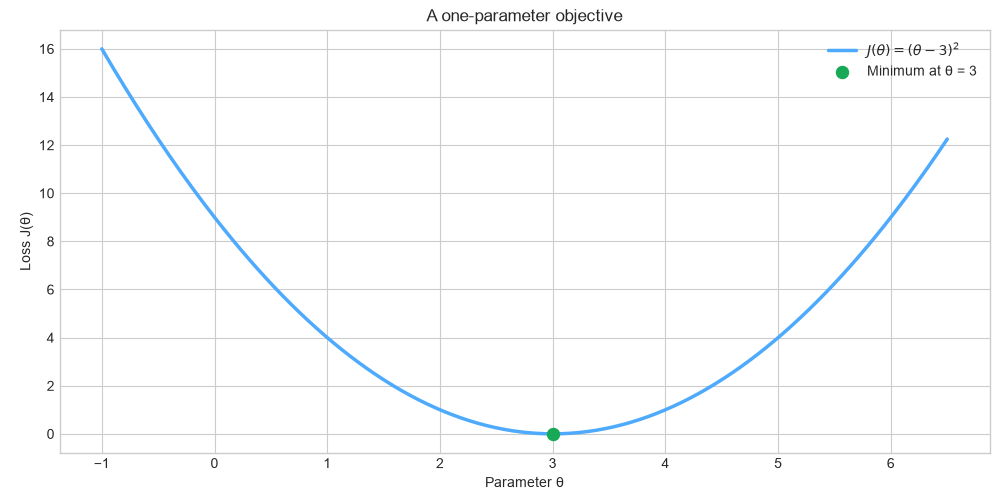

In [2]:
theta_grid = np.linspace(-1.0, 6.5, 300)
objective_grid = (theta_grid - 3.0) ** 2

fig, ax = plt.subplots(figsize=SINGLE_PLOT_FIGSIZE)
ax.plot(theta_grid, objective_grid, color=BLUE, linewidth=2.5, label=r"$J(\theta)=(\theta-3)^2$")
ax.scatter([3.0], [0.0], color=GREEN, s=75, zorder=3, label="Minimum at θ = 3")
ax.set(title="A one-parameter objective", xlabel="Parameter θ", ylabel="Loss J(θ)")
ax.legend()
plt.show()


The curve is bowl-shaped. Values far from 3 produce a large squared loss, while moving towards 3 reduces it. The labelled point identifies the known minimum; colour is not required to distinguish it because the legend also names it.


<a id="one-parameter-gradient"></a>
### <font color="#4DAAFC"><strong>3.1 The gradient gives a direction</strong></font>

We now need a rule for deciding which direction reduces the objective. For a function with one parameter, that local direction is supplied by its derivative.

Start from [Equation (3.1)](#equation-3-1):

$$
\large
J(\theta)=(\theta-3)^2.
$$

Before applying it to this objective, write the power and chain rules in generic form. For any differentiable inner function $g(\theta)$ and constant exponent $n$,

$$
\large
\frac{\mathrm{d}}{\mathrm{d}\theta}\left[g(\theta)\right]^n
=n\left[g(\theta)\right]^{n-1}g'(\theta).
$$

This says: bring the exponent to the front, reduce it by one, and multiply by the derivative of the inner function. Here,

$$
\large
g(\theta)=\theta-3,
\qquad n=2,
\qquad g'(\theta)=1.
$$

Substituting these components into the generic rule gives

$$
\large
\frac{\mathrm{d}J}{\mathrm{d}\theta}
=2(\theta-3)^{2-1}
\frac{\mathrm{d}}{\mathrm{d}\theta}(\theta-3).
$$

Because $\frac{\mathrm{d}}{\mathrm{d}\theta}(\theta-3)=1$, this simplifies to

<a id="equation-3-2"></a>
$$
\large
\frac{\mathrm{d}J}{\mathrm{d}\theta}=2(\theta-3). \tag{3.2}
$$

The sign supplies a direction:

<table>
<thead><tr><th align="left"><font size="4">Current position</font></th><th align="left"><font size="4">Gradient sign</font></th><th align="left"><font size="4">Direction that reduces the loss</font></th></tr></thead>
<tbody>
<tr><td align="left"><font size="4">θ &lt; 3</font></td><td align="left"><font size="4">Negative</font></td><td align="left"><font size="4">Increase θ</font></td></tr>
<tr><td align="left"><font size="4">θ = 3</font></td><td align="left"><font size="4">Zero</font></td><td align="left"><font size="4">No update is needed</font></td></tr>
<tr><td align="left"><font size="4">θ &gt; 3</font></td><td align="left"><font size="4">Positive</font></td><td align="left"><font size="4">Decrease θ</font></td></tr>
</tbody>
</table>

Having calculated the direction, we next need a rule for changing the parameter. Gradient descent uses the update

<a id="equation-3-3"></a>
$$
\large
\theta^{(t+1)}
=\theta^{(t)}-\alpha
\left.\frac{\mathrm{d}J}{\mathrm{d}\theta}\right|_{\theta=\theta^{(t)}}, \tag{3.3}
$$

where $t$ is the current iteration and $\alpha>0$ is the **learning rate**. The learning rate controls the size of the step.

[Equation (3.3)](#equation-3-3) says: evaluate the slope at the current parameter, scale it by the learning rate and move in the opposite direction. Subtracting a positive gradient moves left; subtracting a negative gradient moves right.


<a id="worked-update"></a>
### <font color="#4DAAFC"><strong>3.2 One hand-worked update</strong></font>

This subsection verifies the complete chain numerically before we write any Python. Suppose the initial parameter is $\theta^{(0)}=0$ and the learning rate is $\alpha=0.1$.

**Step 1 — calculate the starting loss.**

Start with the generic objective from [Equation (3.1)](#equation-3-1):

$$
\large
J(\theta)=(\theta-3)^2.
$$

Substitute the initial value $\theta^{(0)}=0$:

$$
\large
J(\theta^{(0)})
=J(0)
=(0-3)^2
=(-3)^2
=9.
$$

The initial loss is therefore 9: the starting parameter is three units from the target, and the objective records the square of that distance.

**Step 2 — calculate the gradient at the starting value.**

Start with the generic derivative from [Equation (3.2)](#equation-3-2):

$$
\large
\frac{\mathrm{d}J}{\mathrm{d}\theta}=2(\theta-3).
$$

Substitute $\theta^{(0)}=0$:

$$
\large
\left.\frac{\mathrm{d}J}{\mathrm{d}\theta}\right|_{\theta=0}
=2(0-3)
=-6.
$$

**Step 3 — use the gradient to update the parameter.**

Restate the generic update from [Equation (3.3)](#equation-3-3):

$$
\large
\theta^{(t+1)}
=\theta^{(t)}-\alpha
\left.\frac{\mathrm{d}J}{\mathrm{d}\theta}\right|_{\theta=\theta^{(t)}}.
$$

At $t=0$, substitute $\theta^{(0)}=0$, $\alpha=0.1$ and the gradient $-6$:

$$
\large
\theta^{(1)}
=\theta^{(0)}-\alpha
\left.\frac{\mathrm{d}J}{\mathrm{d}\theta}\right|_{\theta=\theta^{(0)}}
=0-(0.1)(-6)
=0.6.
$$

**Step 4 — calculate the loss after the update.**

Use [Equation (3.1)](#equation-3-1) again, now with $\theta^{(1)}=0.6$:

$$
\large
J(\theta^{(1)})
=J(0.6)
=(0.6-3)^2
=(-2.4)^2
=5.76.
$$

The parameter moves from 0 to 0.6—towards the minimum at 3—and the loss falls from 9 to 5.76. This single update does not solve the problem, but it confirms that the direction and arithmetic are working together as intended.

> **Calculation chain:** objective $\rightarrow$ starting loss $\rightarrow$ gradient $\rightarrow$ parameter update $\rightarrow$ new loss.


<a id="implement-update"></a>
### <font color="#4DAAFC"><strong>3.3 Implement one update</strong></font>

The following functions separate the objective, gradient and update. That separation makes the mathematical correspondence visible and allows each part to be tested independently.


In [3]:
def quadratic_objective(theta: float) -> float:
    """Evaluate the demonstration objective ``(theta - 3)^2``.

    Parameters
    ----------
    theta
        Current scalar parameter value.

    Returns
    -------
    float
        Non-negative objective value.
    """
    return float((theta - 3.0) ** 2)


def quadratic_gradient(theta: float) -> float:
    """Evaluate the derivative of the demonstration objective.

    Parameters
    ----------
    theta
        Current scalar parameter value.

    Returns
    -------
    float
        Gradient ``2 * (theta - 3)`` at the supplied point.
    """
    return float(2.0 * (theta - 3.0))


def gradient_step(theta: float, gradient: float, learning_rate: float) -> float:
    """Apply one scalar gradient-descent update.

    Parameters
    ----------
    theta
        Parameter value before the update.
    gradient
        Objective gradient evaluated at ``theta``.
    learning_rate
        Positive step-size multiplier.

    Returns
    -------
    float
        Updated parameter value.

    Raises
    ------
    ValueError
        If the learning rate is not positive and finite.
    """
    if not np.isfinite(learning_rate) or learning_rate <= 0:
        raise ValueError("learning_rate must be positive and finite")
    return float(theta - learning_rate * gradient)


In [4]:
theta_0 = 0.0
gradient_0 = quadratic_gradient(theta_0)
theta_1 = gradient_step(theta_0, gradient_0, learning_rate=0.1)

print(f"Initial theta: {theta_0:.1f}")
print(f"Initial gradient: {gradient_0:.1f}")
print(f"Updated theta: {theta_1:.1f}")
print(f"Loss before update: {quadratic_objective(theta_0):.2f}")
print(f"Loss after update: {quadratic_objective(theta_1):.2f}")


Initial theta: 0.0
Initial gradient: -6.0
Updated theta: 0.6
Loss before update: 9.00
Loss after update: 5.76


The output reproduces the hand calculation: the negative gradient moves the parameter from 0.0 to 0.6, and the loss falls from 9.00 to 5.76. Matching the manual and coded results is our first sanity check.


<a id="learning-rate"></a>
## <font color="#4DAAFC"><strong>4. The learning rate controls the journey</strong></font>

The learning rate $\alpha$ is not the direction of travel; the gradient already supplies that. It controls how far the parameter travels during each update.

- A very small learning rate can make progress unnecessarily slow.
- A suitable learning rate can approach the minimum smoothly.
- A learning rate that is too large can overshoot, oscillate or diverge.

The next function records a complete path so that we can inspect these behaviours rather than relying on the final value alone.


In [5]:
def trace_quadratic_descent(
    initial_theta: float,
    learning_rate: float,
    n_steps: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Trace gradient descent on the one-parameter objective.

    Parameters
    ----------
    initial_theta
        Starting parameter value.
    learning_rate
        Positive gradient-step multiplier.
    n_steps
        Number of updates to perform.

    Returns
    -------
    theta_history
        Parameter values with shape ``(n_steps + 1,)``.
    loss_history
        Corresponding objective values with the same shape.
    """
    if n_steps < 1:
        raise ValueError("n_steps must be at least one")

    theta = float(initial_theta)
    theta_history = [theta]
    loss_history = [quadratic_objective(theta)]

    for _ in range(n_steps):
        theta = gradient_step(theta, quadratic_gradient(theta), learning_rate)
        theta_history.append(theta)
        loss_history.append(quadratic_objective(theta))

    return np.asarray(theta_history), np.asarray(loss_history)


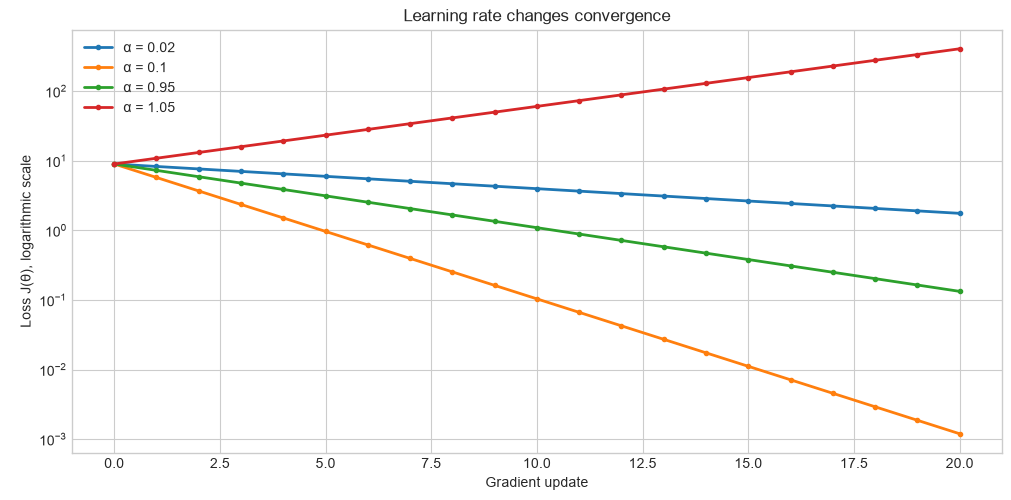

In [6]:
example_rates = [0.02, 0.10, 0.95, 1.05]

fig, ax = plt.subplots(figsize=SINGLE_PLOT_FIGSIZE)
for rate in example_rates:
    _, losses = trace_quadratic_descent(0.0, rate, n_steps=20)
    ax.semilogy(losses, linewidth=2, marker="o", markersize=3, label=f"α = {rate}")

ax.set(title="Learning rate changes convergence", xlabel="Gradient update", ylabel="Loss J(θ), logarithmic scale")
ax.legend()
plt.show()


The learning rate of 0.02 reduces the loss steadily but slowly. Rates 0.10 and 0.95 converge much faster for this particular objective. The rate 1.05 increases the loss because each update overshoots by more than the previous one. This threshold is specific to the curvature of this objective; there is no universally safe learning rate.


<a id="linear-regression"></a>
## <font color="#4DAAFC"><strong>5. Move from one parameter to a fitted line</strong></font>

The scalar example established the complete optimisation cycle with a known minimum. This section transfers that same cycle to a recognisable data-science task: estimating the slope and intercept of a line from noisy observations. We will first define the data and model, then derive the two gradients that the complete runner will use.

Let $x_i\in\mathbb{R}$ be the feature and $y_i\in\mathbb{R}$ the observed target for observation $i$, where $i\in\{1,\ldots,N\}$. Collect the values into the column vectors

$$
\large
\mathbf{x}
=\left(x_1,x_2,\ldots,x_N\right)^{\mathsf T}
\in\mathbb{R}^{N},
\qquad
\mathbf{y}
=\left(y_1,y_2,\ldots,y_N\right)^{\mathsf T}
\in\mathbb{R}^{N}.
$$

As above, $\mathsf T$ denotes the transpose and makes each horizontally written sequence an $N\times 1$ column vector. We reserve vertical matrix notation for the short concrete example below, where every element can be shown without an unusually tall delimiter.

For a three-observation example, these could be

$$
\large
\mathbf{x}=\begin{bmatrix}-1\\0\\2\end{bmatrix},
\qquad
\mathbf{y}=\begin{bmatrix}-3\\-1\\4\end{bmatrix}.
$$

NumPy represents them as `np.array([-1.0, 0.0, 2.0])` and `np.array([-3.0, -1.0, 4.0])`, each with shape `(3,)`.

The model has two parameters:

- $w\in\mathbb{R}$: the slope or weight;
- $b\in\mathbb{R}$: the intercept or bias.

The parameter vector is therefore

$$
\large
\boldsymbol{\theta}
=\begin{bmatrix}w\\b\end{bmatrix}
\in\mathbb{R}^{2}.
$$

In the implementation we keep `weight` and `bias` as named scalars because their roles are easier for a beginner to follow, while recognising that they form one mathematical parameter vector.


<a id="model-loss"></a>
### <font color="#4DAAFC"><strong>5.1 Model and loss</strong></font>

This subsection defines what the line predicts and how prediction error becomes one scalar objective. That objective is the function we will differentiate in Section 5.2.

The prediction for observation $i$ is

<a id="equation-5-1"></a>
$$
\large
\hat{y}_i=wx_i+b, \tag{5.1}
$$

where $\hat{y}_i$ is the predicted target. The residual is $\hat{y}_i-y_i$: prediction minus observation.

We measure overall disagreement with the mean squared error (MSE):

<a id="equation-5-2"></a>
$$
\large
J(w,b)=\frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)^2. \tag{5.2}
$$

[Equation (5.2)](#equation-5-2) squares every residual so that positive and negative errors cannot cancel, then averages those squared errors over the $N$ observations. The square is also differentiable everywhere, which allows us to derive smooth gradient updates. Other loss functions can be appropriate, but comparing them is outside this first pilot.


In [7]:
n_observations = 60
x = np.linspace(-2.5, 3.0, n_observations)
true_weight = 2.4
true_bias = -0.7
noise = rng.normal(loc=0.0, scale=0.65, size=n_observations)
y = true_weight * x + true_bias + noise

print(f"Feature shape: {x.shape}")
print(f"Target shape: {y.shape}")
print(f"First three observations: {np.round(np.column_stack((x, y))[:3], 3)}")


Feature shape: (60,)
Target shape: (60,)
First three observations: [[-2.5   -6.779]
 [-2.407 -6.491]
 [-2.314 -6.834]]


Both arrays have shape `(60,)`: one feature and one target for each of 60 observations. The noisy targets do not sit exactly on the hidden generating line, which makes the example closer to a real estimation problem.


<a id="linear-gradients"></a>
### <font color="#4DAAFC"><strong>5.2 Gradients for the weight and bias</strong></font>

To update both model parameters, we need to know how the loss changes when each one changes. This subsection derives those two quantities directly from the model and loss defined in [Equations (5.1)](#equation-5-1) and [(5.2)](#equation-5-2).

The symbol $\partial$ denotes a **partial derivative**: the rate of change with respect to one parameter while the other parameter is temporarily held fixed.

### Derive the weight gradient

Start by substituting the prediction $\hat{y}_i=wx_i+b$ from [Equation (5.1)](#equation-5-1) into the MSE objective:

$$
\large
J(w,b)
=\frac{1}{N}\sum_{i=1}^{N}(wx_i+b-y_i)^2.
$$

The constant $1/N$ remains outside the derivative, and differentiation passes through the finite sum:

$$
\large
\frac{\partial J}{\partial w}
=\frac{1}{N}\sum_{i=1}^{N}
\frac{\partial}{\partial w}(wx_i+b-y_i)^2.
$$

For each observation, apply the chain rule. The derivative of the outer square is twice its input, while the inner derivative is

$$
\large
\frac{\partial}{\partial w}(wx_i+b-y_i)=x_i.
$$

Therefore

$$
\large
\frac{\partial J}{\partial w}
=\frac{1}{N}\sum_{i=1}^{N}
2(wx_i+b-y_i)x_i.
$$

Replacing $wx_i+b$ with $\hat{y}_i$ and moving the constant 2 outside the sum gives

<a id="equation-5-3"></a>
$$
\large
\frac{\partial J}{\partial w}
=\frac{2}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i)x_i. \tag{5.3}
$$

[Equation (5.3)](#equation-5-3) weights each residual by $x_i$ because changing the slope changes observation $i$'s prediction in proportion to its feature value.

### Derive the bias gradient

Begin from the same substituted objective, but differentiate with respect to $b$:

$$
\large
\frac{\partial J}{\partial b}
=\frac{1}{N}\sum_{i=1}^{N}
\frac{\partial}{\partial b}(wx_i+b-y_i)^2.
$$

The outer derivative is again twice the residual. This time the inner derivative is

$$
\large
\frac{\partial}{\partial b}(wx_i+b-y_i)=1,
$$

because increasing the intercept shifts every prediction by the same amount. Hence

$$
\large
\frac{\partial J}{\partial b}
=\frac{1}{N}\sum_{i=1}^{N}
2(wx_i+b-y_i)(1).
$$

Substituting $\hat{y}_i=wx_i+b$ and simplifying gives

<a id="equation-5-4"></a>
$$
\large
\frac{\partial J}{\partial b}
=\frac{2}{N}\sum_{i=1}^{N}(\hat{y}_i-y_i). \tag{5.4}
$$

[Equation (5.4)](#equation-5-4) averages the residual contribution because the intercept changes every prediction equally.

### Combine the two updates

Apply the same generic gradient-descent rule used in [Equation (3.3)](#equation-3-3) to each parameter:

<a id="equation-5-5"></a>
$$
\large
w^{(t+1)}=w^{(t)}-\alpha\frac{\partial J}{\partial w},
\qquad
b^{(t+1)}=b^{(t)}-\alpha\frac{\partial J}{\partial b}. \tag{5.5}
$$

> **From mathematics to code:** one function will calculate the predictions and residuals once, then use them in [Equations (5.2)](#equation-5-2), [(5.3)](#equation-5-3) and [(5.4)](#equation-5-4).


<a id="gradient-function"></a>
### <font color="#4DAAFC"><strong>5.3 One vectorised gradient calculation</strong></font>

The derivations have reduced the problem to predictions, residuals, their mean square and two weighted averages. This subsection implements precisely that chain. NumPy calculates all observations together, and one function returns the quantities defined by [Equations (5.2)](#equation-5-2), [(5.3)](#equation-5-3) and [(5.4)](#equation-5-4).


In [8]:
def validate_regression_data(
    features: np.ndarray,
    targets: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Validate a single-feature regression dataset.

    Parameters
    ----------
    features
        Feature values with shape ``(N,)``.
    targets
        Target values with the same shape.

    Returns
    -------
    features, targets
        Finite floating-point arrays with matching non-empty shapes.
    """
    features = np.asarray(features, dtype=float)
    targets = np.asarray(targets, dtype=float)
    if features.ndim != 1 or targets.ndim != 1 or features.size == 0:
        raise ValueError("features and targets must be non-empty one-dimensional arrays")
    if features.shape != targets.shape:
        raise ValueError("features and targets must have the same shape")
    if not np.all(np.isfinite(features)) or not np.all(np.isfinite(targets)):
        raise ValueError("features and targets must be finite")
    return features, targets


def linear_loss_and_gradients(
    features: np.ndarray,
    targets: np.ndarray,
    weight: float,
    bias: float,
) -> tuple[float, float, float]:
    """Calculate mean squared error and its two linear-model gradients.

    Parameters
    ----------
    features
        Feature values with shape ``(N,)``.
    targets
        Observed target values with shape ``(N,)``.
    weight
        Current line slope ``w``.
    bias
        Current line intercept ``b``.

    Returns
    -------
    loss
        Mean squared error for the current parameters.
    weight_gradient
        Partial derivative of the loss with respect to ``w``.
    bias_gradient
        Partial derivative of the loss with respect to ``b``.
    """
    features, targets = validate_regression_data(features, targets)
    predictions = weight * features + bias
    residuals = predictions - targets

    loss = np.mean(residuals**2)
    weight_gradient = 2.0 * np.mean(residuals * features)
    bias_gradient = 2.0 * np.mean(residuals)
    return float(loss), float(weight_gradient), float(bias_gradient)


In [9]:
initial_loss, initial_dw, initial_db = linear_loss_and_gradients(
    x,
    y,
    weight=0.0,
    bias=0.0,
)

print(f"Initial MSE: {initial_loss:.3f}")
print(f"Weight gradient ∂J/∂w: {initial_dw:.3f}")
print(f"Bias gradient ∂J/∂b: {initial_db:.3f}")


Initial MSE: 15.675
Weight gradient ∂J/∂w: -12.594
Bias gradient ∂J/∂b: 0.161


At the initial horizontal line `ŷ = 0`, both gradients are positive or negative according to this fixed dataset. Subtracting them in equation (5.5) moves the slope and intercept in the directions that locally reduce mean squared error. Their different magnitudes are expected because the two parameters affect predictions differently.


<a id="fit-runner"></a>
## <font color="#4DAAFC"><strong>6. Assemble batch gradient descent</strong></font>

Sections 3 and 5 developed the update rule and the two regression gradients separately. This section assembles them into the complete fitting loop so the same calculations can be repeated until the parameters stabilise. **Batch gradient descent** uses all observations to calculate each update, and the runner records its history for diagnosis.


In [10]:
@dataclass(frozen=True)
class GradientDescentResult:
    """Final parameters and recorded optimisation history."""

    weight: float
    bias: float
    losses: np.ndarray
    weights: np.ndarray
    biases: np.ndarray


def fit_linear_gradient_descent(
    features: np.ndarray,
    targets: np.ndarray,
    learning_rate: float = 0.05,
    n_steps: int = 300,
    initial_weight: float = 0.0,
    initial_bias: float = 0.0,
) -> GradientDescentResult:
    """Fit a one-feature linear model with batch gradient descent.

    Parameters
    ----------
    features
        Feature values with shape ``(N,)``.
    targets
        Target values with shape ``(N,)``.
    learning_rate
        Positive multiplier applied to both gradients.
    n_steps
        Number of parameter updates.
    initial_weight, initial_bias
        Starting line parameters.

    Returns
    -------
    GradientDescentResult
        Final parameters and histories including the initial state.
    """
    features, targets = validate_regression_data(features, targets)
    if not np.isfinite(learning_rate) or learning_rate <= 0:
        raise ValueError("learning_rate must be positive and finite")
    if n_steps < 1:
        raise ValueError("n_steps must be at least one")

    weight = float(initial_weight)
    bias = float(initial_bias)
    losses = []
    weights = [weight]
    biases = [bias]

    for _ in range(n_steps):
        loss, weight_gradient, bias_gradient = linear_loss_and_gradients(
            features, targets, weight, bias
        )
        losses.append(loss)
        weight -= learning_rate * weight_gradient
        bias -= learning_rate * bias_gradient
        weights.append(weight)
        biases.append(bias)

    final_loss, _, _ = linear_loss_and_gradients(features, targets, weight, bias)
    losses.append(final_loss)

    return GradientDescentResult(
        weight=weight,
        bias=bias,
        losses=np.asarray(losses),
        weights=np.asarray(weights),
        biases=np.asarray(biases),
    )


<a id="fit-model"></a>
## <font color="#4DAAFC"><strong>7. Fit and inspect the model</strong></font>

The complete runner now gives us something we can test rather than merely inspect as code. This section applies it to the demonstration data and checks both the estimated line and the full loss history. We use a learning rate of 0.05 for 300 updates; the fitted parameters should approach the relationship that generated the data, although random noise means they need not equal it exactly.


In [11]:
fitted = fit_linear_gradient_descent(
    x,
    y,
    learning_rate=0.05,
    n_steps=300,
)

print(f"Fitted weight: {fitted.weight:.3f} (generating value {true_weight:.1f})")
print(f"Fitted bias: {fitted.bias:.3f} (generating value {true_bias:.1f})")
print(f"Initial MSE: {fitted.losses[0]:.3f}")
print(f"Final MSE: {fitted.losses[-1]:.3f}")


Fitted weight: 2.424 (generating value 2.4)
Fitted bias: -0.686 (generating value -0.7)
Initial MSE: 15.675
Final MSE: 0.355


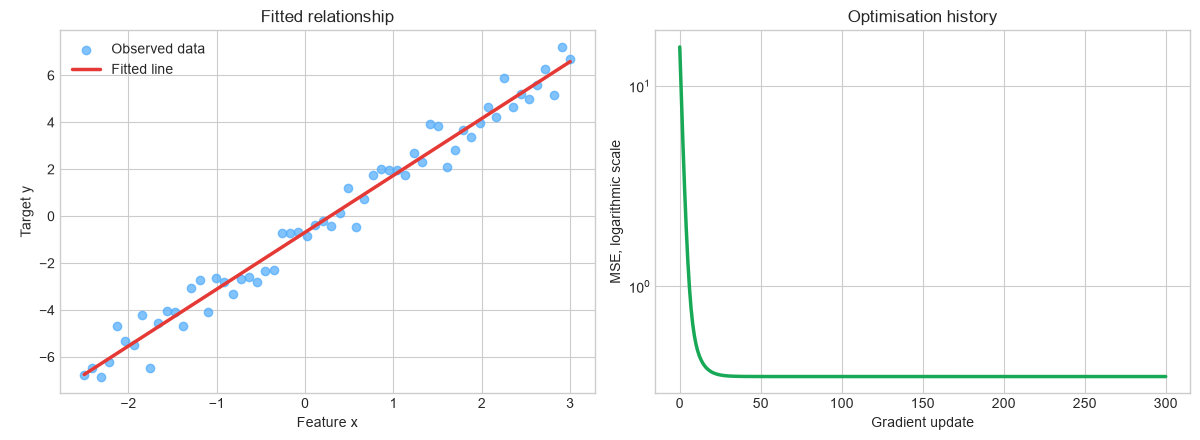

In [12]:
fitted_predictions = fitted.weight * x + fitted.bias

fig, axes = plt.subplots(1, 2, figsize=TWO_PANEL_FIGSIZE)

axes[0].scatter(x, y, alpha=0.7, color=BLUE, label="Observed data")
axes[0].plot(x, fitted_predictions, color=RED, linewidth=2.5, label="Fitted line")
axes[0].set(title="Fitted relationship", xlabel="Feature x", ylabel="Target y")
axes[0].legend()

axes[1].semilogy(fitted.losses, color=GREEN, linewidth=2.5)
axes[1].set(title="Optimisation history", xlabel="Gradient update", ylabel="MSE, logarithmic scale")

plt.tight_layout()
plt.show()


The left panel shows that the fitted line follows the centre of the noisy observations. The right panel shows a smooth reduction in mean squared error (MSE), with large improvements early in training and progressively smaller changes near convergence. Together, the numerical output and plots indicate that the implementation is behaving as intended on this demonstration dataset.


<a id="compare-rates"></a>
## <font color="#4DAAFC"><strong>8. Compare learning rates</strong></font>

A successful fit under one setting does not explain how sensitive the method is to its step size. This section compares complete loss histories under different learning rates while keeping the starting values and data fixed, isolating the effect of $\alpha$.


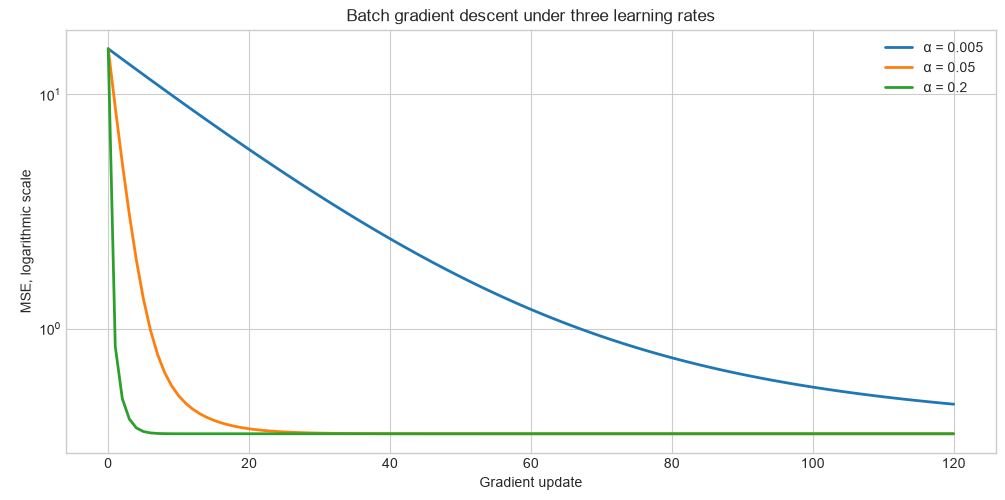

In [13]:
regression_rates = [0.005, 0.05, 0.20]

fig, ax = plt.subplots(figsize=SINGLE_PLOT_FIGSIZE)
for rate in regression_rates:
    result = fit_linear_gradient_descent(x, y, learning_rate=rate, n_steps=120)
    ax.semilogy(result.losses, linewidth=2, label=f"α = {rate}")

ax.set(title="Batch gradient descent under three learning rates", xlabel="Gradient update", ylabel="MSE, logarithmic scale")
ax.legend()
plt.show()


The smallest rate makes gradual progress. The intermediate and larger rates reach the low-loss region more quickly on this well-scaled, one-feature problem. A larger value is not inherently better: with different feature scales or curvature it may become unstable. The loss history is therefore an important diagnostic, not merely a decorative plot.


<a id="checks"></a>
## <font color="#4DAAFC"><strong>9. Sanity checks and limitations</strong></font>

Plots can look convincing even when an implementation is subtly wrong. This section converts several expected behaviours into explicit checks, then states what the controlled example cannot establish. These tests do not prove correctness for every possible dataset, but they can expose common errors.


In [14]:
# Check the hand-worked calculation.
assert np.isclose(theta_1, 0.6)
assert quadratic_objective(theta_1) < quadratic_objective(theta_0)

# Check the fitted history and parameter estimates.
assert fitted.losses[-1] < fitted.losses[0]
assert np.all(np.diff(fitted.losses) <= 1e-10)
assert abs(fitted.weight - true_weight) < 0.25
assert abs(fitted.bias - true_bias) < 0.25

# Check an important input boundary.
try:
    fit_linear_gradient_descent(x, y[:-1])
except ValueError:
    mismatched_shapes_rejected = True
else:
    mismatched_shapes_rejected = False

assert mismatched_shapes_rejected
print("All demonstration checks passed.")


All demonstration checks passed.


### Limitations

- This is full-batch gradient descent on a small, single-feature linear model.
- Real applications may use **stochastic gradient descent (SGD)** or mini-batches rather than every observation in each update.
- Feature scaling becomes more important when predictors have very different magnitudes.
- Mean squared error is sensitive to unusually large residuals and is not appropriate for every problem.
- A falling training loss does not establish performance on unseen data; that requires a validation or test design.
- More complex objectives may contain saddle points, flat regions and multiple local minima.


<a id="summary"></a>
## <font color="#4DAAFC"><strong>10. Summary and next steps</strong></font>

This Learning Lab followed one continuous chain from an objective to a fitted model:

1. [Equation (2.1)](#equation-2-1) defined optimisation as the search for parameters that minimise a loss.
2. [Equation (3.1)](#equation-3-1) introduced a one-parameter objective with a known minimum.
3. [Equation (3.2)](#equation-3-2) derived its local slope.
4. [Equation (3.3)](#equation-3-3) turned that slope into an iterative parameter update.
5. [Equations (5.1)](#equation-5-1) and [(5.2)](#equation-5-2) defined a straight-line prediction and its mean squared error.
6. [Equations (5.3)](#equation-5-3) and [(5.4)](#equation-5-4) derived the gradients for the slope and intercept.
7. [Equation (5.5)](#equation-5-5) applied the update rule to both parameters.

The general vector form that connects both examples is

$$
\large
\boldsymbol{\theta}^{(t+1)}
=\boldsymbol{\theta}^{(t)}
-\alpha\nabla J(\boldsymbol{\theta}^{(t)}),
$$

where $\nabla J$ is the vector of partial derivatives. In the regression example,

$$
\large
\boldsymbol{\theta}
=\begin{bmatrix}w\\b\end{bmatrix},
\qquad
\nabla J(\boldsymbol{\theta})
=\begin{bmatrix}
\partial J/\partial w\\
\partial J/\partial b
\end{bmatrix}.
$$

The gradient supplies the local direction, while the learning rate $\alpha$ controls the step size. On the fixed demonstration dataset, this combination reduced the mean squared error and recovered a line close to the generating relationship.

> **What we have demonstrated:** the mathematics, code and recorded outputs agree for a controlled one-feature regression problem. We have not established that the same learning rate or model is suitable for unseen or differently scaled data.

Purposeful next steps include extending the implementation to several features, comparing batch and stochastic gradient descent, introducing feature scaling and examining adaptive optimisers used in neural networks.
